In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../Resources/TF_2_Notebooks_and_Data/DATA/RSCCASN.csv", parse_dates=True, index_col="DATE")
df.head()

,RSCCASN
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 334 entries, 1992-01-01 to 2019-10-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   RSCCASN  334 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


In [4]:
df.columns = ['SALES']

In [5]:
df.head()

,SALES
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


<Axes: xlabel='DATE'>

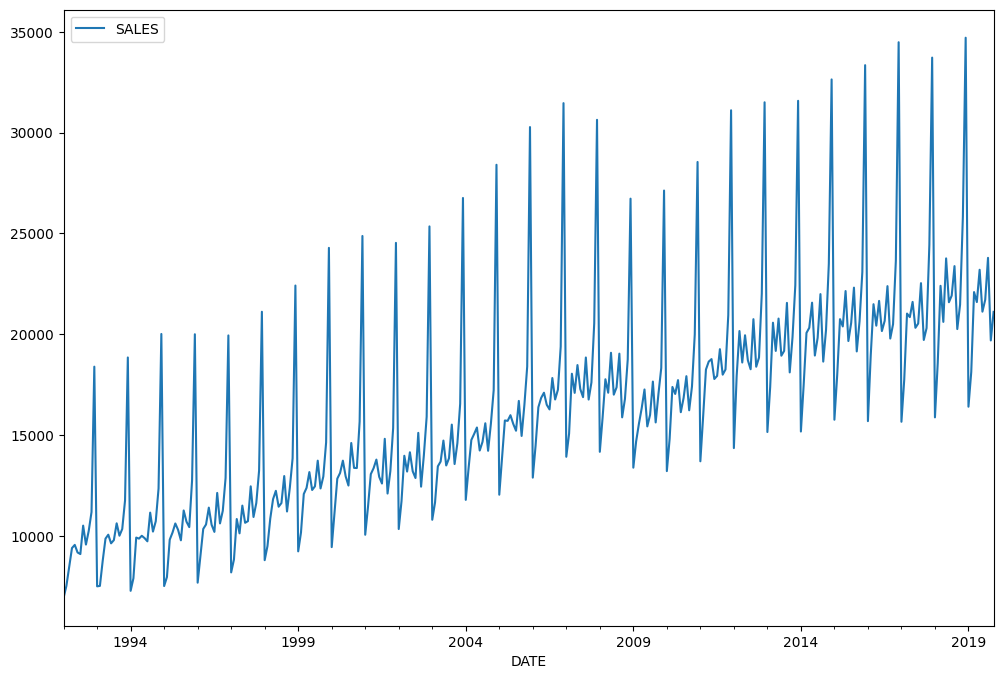

In [6]:
df.plot(figsize=(12, 8))

In [7]:
len(df), len(df) - 18 #

(334, 316)

In [8]:
test_size = 18
test_idx = len(df) - test_size

In [9]:
train = df.iloc[:test_idx]
test = df.iloc[test_idx:]
train, test

(            SALES
 DATE             
 1992-01-01   6938
 1992-02-01   7524
 1992-03-01   8475
 1992-04-01   9401
 1992-05-01   9558
 ...           ...
 2017-12-01  33720
 2018-01-01  15881
 2018-02-01  18585
 2018-03-01  22404
 2018-04-01  20616
 
 [316 rows x 1 columns],
             SALES
 DATE             
 2018-05-01  23764
 2018-06-01  21589
 2018-07-01  21919
 2018-08-01  23381
 2018-09-01  20260
 2018-10-01  21473
 2018-11-01  25831
 2018-12-01  34706
 2019-01-01  16410
 2019-02-01  18134
 2019-03-01  22093
 2019-04-01  21597
 2019-05-01  23200
 2019-06-01  21123
 2019-07-01  21714
 2019-08-01  23791
 2019-09-01  19695
 2019-10-01  21113)

In [10]:
#  Prerocessing
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()
scaler.fit(train)

MinMaxScaler()

In [12]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [13]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [14]:
len(test)

18

In [15]:
length = 12 # months batch
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=1)
generator

In [16]:
X, y = generator[0]

In [17]:
X # checking for 12 months

array([[[0.        ],
        [0.02127505],
        [0.05580163],
        [0.08942056],
        [0.09512053],
        [0.08146965],
        [0.07860151],
        [0.12979233],
        [0.09566512],
        [0.1203892 ],
        [0.15426227],
        [0.41595266]]])

In [18]:
y # getting the 13th month

array([[0.02047633]])

In [19]:
scaled_train[:13] # from our scaled data, we got a good pred

array([[0.        ],
       [0.02127505],
       [0.05580163],
       [0.08942056],
       [0.09512053],
       [0.08146965],
       [0.07860151],
       [0.12979233],
       [0.09566512],
       [0.1203892 ],
       [0.15426227],
       [0.41595266],
       [0.02047633]])

In [20]:
# Creating model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [21]:
num_features = 1

In [22]:
model = Sequential()

# Add the Input layer explicitly
model.add(Input(shape=(length, num_features)))

# Add LSTM layer
model.add(LSTM(100, activation="relu"))

# Add Dense layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer="adam", loss="mse")

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [26]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test, length=length, batch_size=1)

In [27]:
model.fit(generator, epochs=20, validation_data=validation_generator, callbacks=[early_stop])

Epoch 1/20
 66/304 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0578  

/Users/sabbha/Python-AI/TensorKeras/.tenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0307 - val_loss: 0.0115
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0155 - val_loss: 0.0026
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0102 - val_loss: 4.4513e-04
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0095 - val_loss: 4.0129e-04
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - val_loss: 0.0073
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0026


In [28]:
losses = pd.DataFrame(model.history.history)

<Axes: >

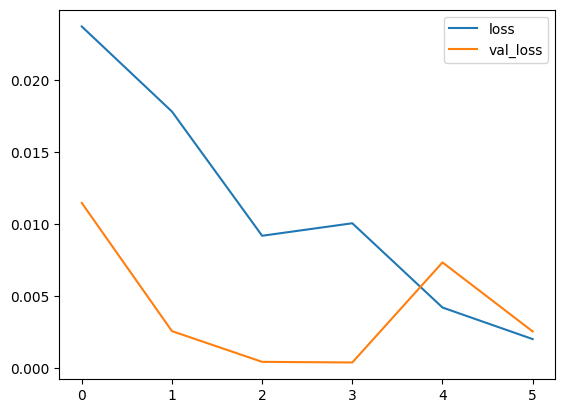

In [29]:
losses.plot()

In [30]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, num_features))

for i in range(len(test)):
    
    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    test_predictions.append(current_pred) 
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [31]:
current_batch, current_batch.shape

(array([[[0.67350549],
         [1.04249942],
         [0.40103137],
         [0.47971779],
         [0.59455359],
         [0.54082733],
         [0.59841335],
         [0.56561291],
         [0.57401454],
         [0.63280416],
         [0.56082553],
         [0.5842638 ]]]),
 (1, 12, 1))

In [32]:
true_predictions = scaler.inverse_transform(test_predictions)

In [33]:
test['Predictions'] = true_predictions

/var/folders/1l/jh7lxvwd53g4g8kvvttg5mn00000gn/T/ipykernel_5596/4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


In [34]:
test

,SALES,Predictions
DATE,,
2018-05-01,23764,22423.514526
2018-06-01,21589,21362.462777
2018-07-01,21919,21585.066063
2018-08-01,23381,23350.305575
2018-09-01,20260,21026.071416
2018-10-01,21473,21630.535980
2018-11-01,25831,25489.035080
2018-12-01,34706,35652.604108
2019-01-01,16410,17984.008191


<Axes: xlabel='DATE'>

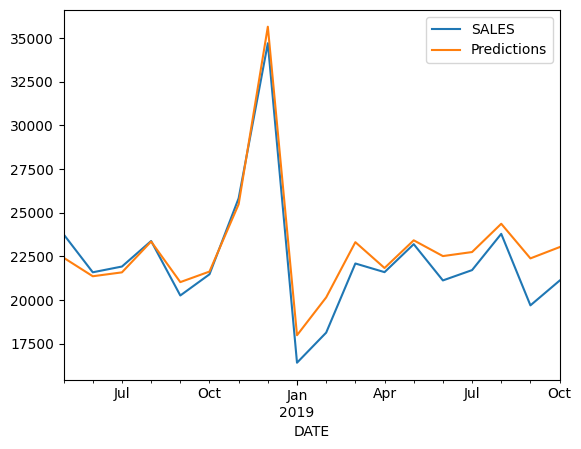

In [35]:
test.plot()

# Retrain and Forecasting

In [36]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

In [37]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data, scaled_full_data, length=length, batch_size=1)

In [38]:
model = Sequential()

# Add the Input layer explicitly
model.add(Input(shape=(length, num_features)))

# Add LSTM layer
model.add(LSTM(100, activation="relu"))

# Add Dense layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer="adam", loss="mse")

model.fit(generator, epochs=8)

Epoch 1/8
 76/322 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0783  

/Users/sabbha/Python-AI/TensorKeras/.tenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0433
Epoch 2/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0163
Epoch 3/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0144
Epoch 4/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0068
Epoch 5/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0045
Epoch 6/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035
Epoch 7/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0029
Epoch 8/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0017


In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,705 (479.32 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,804 (319.55 KB)

In [40]:
forecast = []
# Replace periods with whatever forecast length you want
periods = 12

first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, num_features))

for i in range(periods):
    
    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    forecast.append(current_pred) 
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [41]:
forecast = scaler.inverse_transform(forecast)

In [43]:
df

,SALES
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2019-06-01,21123
2019-07-01,21714
2019-08-01,23791


In [42]:
forecast

array([[26612.62602568],
       [35437.52496338],
       [17424.00879335],
       [19135.63859034],
       [22468.17506075],
       [22115.65021992],
       [23592.61479092],
       [21864.05198097],
       [22497.63298702],
       [24357.55880833],
       [20893.79559183],
       [22265.36471653]])

In [44]:
forecast_idx = pd.date_range(start='2019-11-01',periods=periods,freq='MS')
forecast_idx

DatetimeIndex(['2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01',
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01'],
              dtype='datetime64[ns]', freq='MS')

In [47]:
forecast_df = pd.DataFrame(data=forecast,index=forecast_idx,
                           columns=['Forecast'])
forecast_df

,Forecast
2019-11-01,26612.626026
2019-12-01,35437.524963
2020-01-01,17424.008793
2020-02-01,19135.638590
2020-03-01,22468.175061
2020-04-01,22115.650220
2020-05-01,23592.614791
2020-06-01,21864.051981
2020-07-01,22497.632987
2020-08-01,24357.558808


<Axes: >

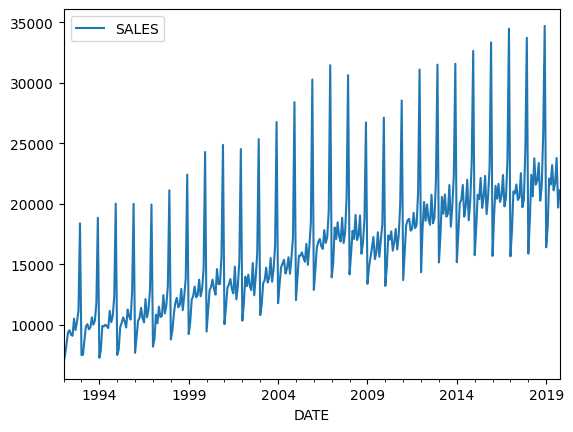

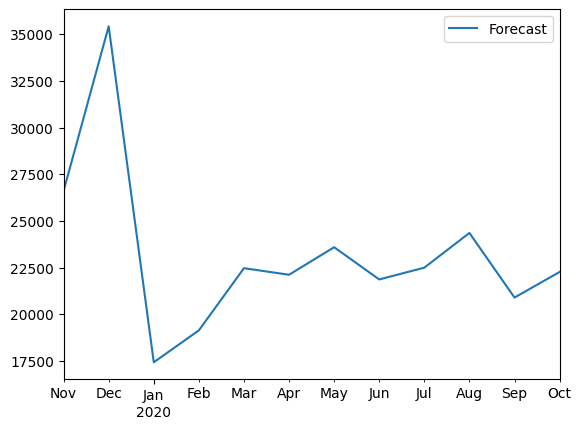

In [48]:
df.plot()
forecast_df.plot()

<Axes: xlabel='DATE'>

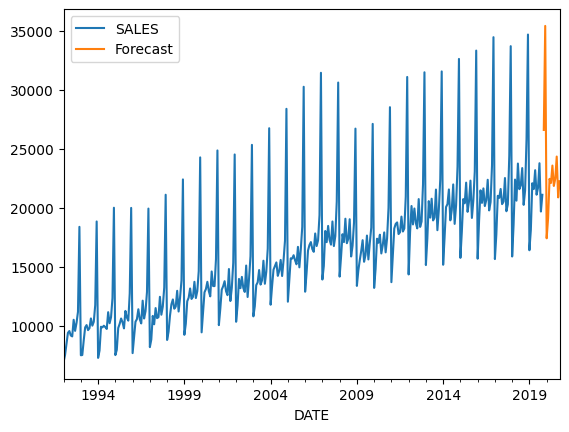

In [50]:
ax = df.plot()
forecast_df.plot(ax=ax)

(576.0, 611.0)

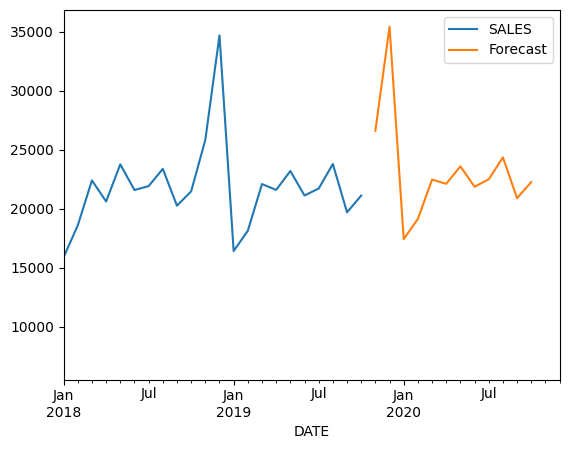

In [51]:
ax = df.plot()
forecast_df.plot(ax=ax)
plt.xlim('2018-01-01','2020-12-01')